In [50]:
import json
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from sklearn.metrics import roc_curve, auc

In [68]:
# This function will always grab the "latest" version of your results
def get_model_data(filename):
    with open(filename, 'r') as f:
        return json.load(f)

# Load everything in one go
data = {
    'SVM': get_model_data('svm_results.json'),
    'CNN': get_model_data('cnn_results.json'),
    'BERT': get_model_data('bert_results.json')
}

# Convert to a DataFrame for easy plotting
df = pd.DataFrame(data).T
print("Current Results:")
display(df)

Current Results:


,accuracy,precision,recall,f1
SVM,0.754583,0.739592,0.754583,0.744854
CNN,0.796667,0.796777,0.796667,0.796667
BERT,0.807900,0.786000,0.807900,0.788900


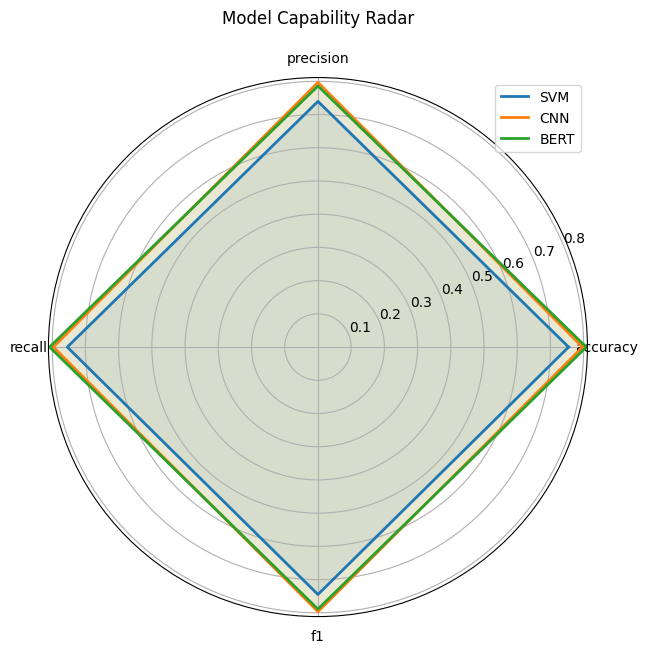

In [ ]:
# RADAR CHART: Model Capability Profile
metrics = df.columns
num_vars = len(metrics)
angles = np.linspace(0, 2 * np.pi, num_vars, endpoint=False).tolist()
angles += angles[:1]

fig, ax = plt.subplots(figsize=(7, 7), subplot_kw=dict(polar=True))
for model in df.index:
    values = df.loc[model].tolist()
    values += values[:1]
    ax.plot(angles, values, label=model, linewidth=2)
    ax.fill(angles, values, alpha=0.1)

ax.set_xticks(angles[:-1])
ax.set_xticklabels(metrics)
plt.title('Model Capability Radar', pad=20)
plt.legend(loc='upper right')
plt.show()

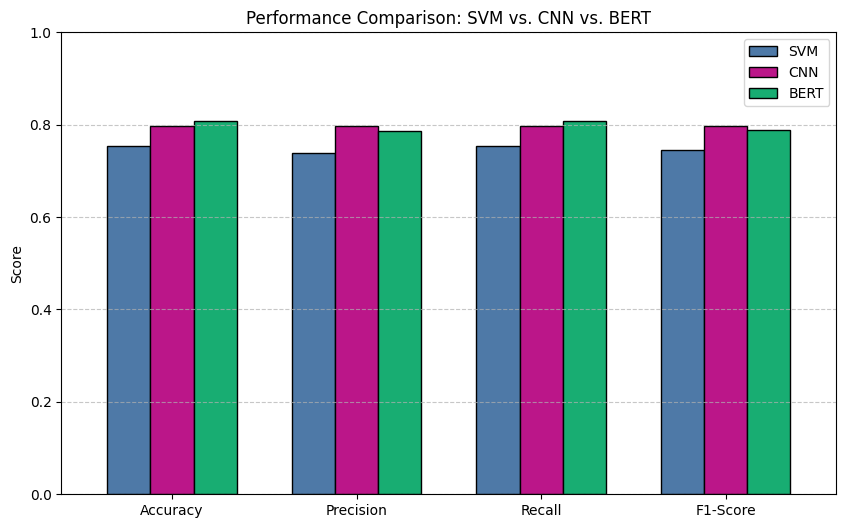

In [56]:
#Bar Chart
files = {'SVM': 'svm_results.json', 'CNN': 'cnn_results.json', 'BERT': 'bert_results.json'}
loaded_data = {}

for model, file in files.items():
    with open(file, 'r') as f:
        content = json.load(f)
        loaded_data[model] = [content['accuracy'], content['precision'], content['recall'], content['f1']]

df = pd.DataFrame(loaded_data, index=['Accuracy', 'Precision', 'Recall', 'F1-Score'])

ax = df.plot(kind='bar', figsize=(10, 6), edgecolor='black', 
             color=['#4E79A7', "#BB1689", "#18AD72"], width=0.7)

plt.yticks(np.arange(0, 1.1, 0.2))
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.title('Performance Comparison: SVM vs. CNN vs. BERT')
plt.ylabel('Score')
plt.xticks(rotation=0)
plt.show()

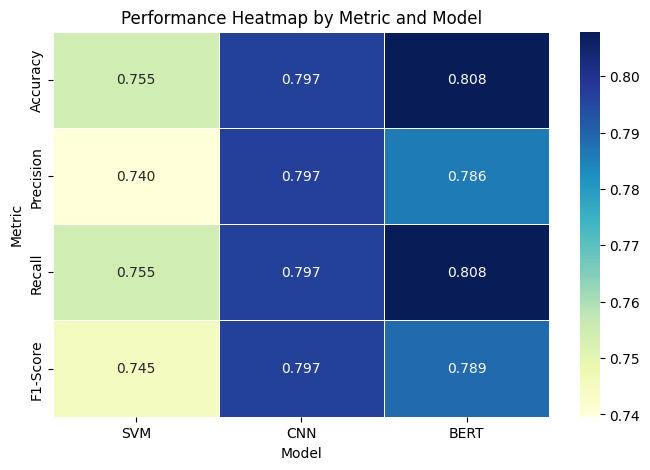

In [ ]:
# Heatmap for Models
plt.figure(figsize=(8, 5))
sns.heatmap(df, annot=True, cmap="YlGnBu", fmt=".3f", linewidths=.5)
plt.title('Performance Heatmap by Metric and Model')
plt.ylabel('Metric')
plt.xlabel('Model')
plt.show()

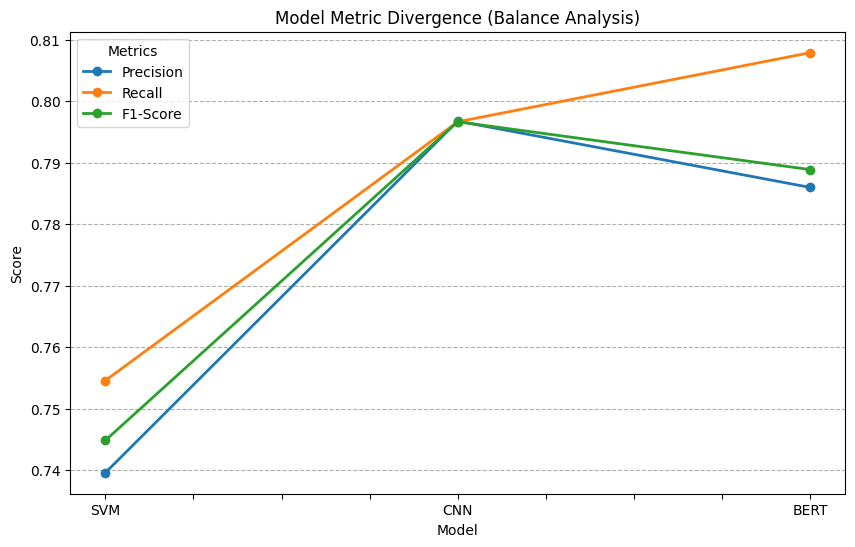

In [67]:
df_transposed = df.T.drop(columns=['Accuracy']) 

ax = df_transposed.plot(marker='o', figsize=(10, 6), linewidth=2)

plt.title('Model Metric Divergence (Balance Analysis)')
plt.ylabel('Score')
plt.xlabel('Model')
plt.grid(axis='y', linestyle='--')
plt.legend(title='Metrics') 
plt.show()